### Parallelization

In langgraph, nodes typically execute in a sequence defined by edges, but when tasks don't depend on each other's outputs, you can run them in parallel. This can be achieved by:
- Defining multiple nodes that can operate independently.
- Connecting them to a common starting point.
- Merging their outputs into a downstream node if needed.

Usecase:
- To generate a full story for given characters, settings, and premise.

In [30]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain.chat_models import init_chat_model


In [31]:
#base model

model = init_chat_model(model="groq:llama-3.1-8b-instant")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002C8EF82E840>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002C8EF82D6D0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [32]:
#defining state schema

from pydantic import BaseModel, Field
from typing import List, Annotated
from typing_extensions import TypedDict

class State(TypedDict):
    topic:str 
    characters:str = ""
    settings:str = ""
    premise:str = ""
    story:str = ""


In [33]:
#defining paralle node functions

#characters generation node

def char_generation(state:State):
    "this function provides characters of the story"
    char_gen = model.invoke(f"generate two characters with traits for the story of given topic. \n Topic: {state['topic']}")
    return {'characters':char_gen.content}

#setting generation node

def setting_generation(state:State):
    "this function provides settings for the story"
    prompt = f"generate few basic background plot or settings for the story of given topic with two characters.\n Topic: {state['topic']}"
    setting_gen = model.invoke(prompt)
    return {'settings':setting_gen.content}

#premise generation node

def premise_generation(state:State):
    "this function generates the simple premise for the story"
    prompt = f"""
                generate simple premise with two characters for the story of given topic.\n
                Topic: {state['topic']}"""
    
    premise_gen = model.invoke(prompt)
    return {'premise':premise_gen.content}

    


In [34]:
#defining aggregator node

def story_generation(state:State):
    "this function generates story based on given inputs"
    prompt =f"""
            Create a simple story of about 500 words using given information.\n
            characters in story: {state['characters']}\n
            settings of the story: {state['settings']}\n
            premise of the story: {state['premise']}"""
    
    story_gen = model.invoke(prompt)
    return {'story':story_gen.content}

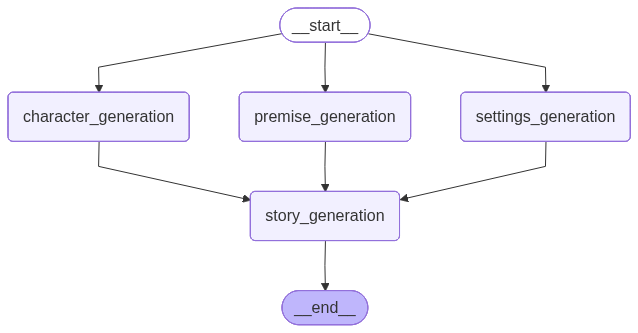

In [35]:
#defining nodes and edges for graph workflow
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node("character_generation", char_generation)
graph_builder.add_node("settings_generation", setting_generation)
graph_builder.add_node("premise_generation", premise_generation)
graph_builder.add_node("story_generation", story_generation)

graph_builder.add_edge(START, "character_generation")
graph_builder.add_edge(START, "settings_generation")
graph_builder.add_edge(START, "premise_generation")
graph_builder.add_edge("character_generation", "story_generation")
graph_builder.add_edge("settings_generation", "story_generation")
graph_builder.add_edge("premise_generation", "story_generation")
graph_builder.add_edge("story_generation", END)

graph = graph_builder.compile()
graph



In [36]:
#graph invocation

result = graph.invoke({'topic':"a boy in beach"})
result

{'topic': 'a boy in beach',
 'characters': 'Here are two character profiles for a story about a boy at the beach:\n\n**Character 1: The Boy (Protagonist)**\n\nName: Max Wells\n\nAge: 12\n\nTraits:\n\n- Age: 12 (young and energetic)\n- Appearance: Max has short, messy brown hair and bright blue eyes. He stands about 5\'3" with a lean athletic build.\n- Personality: Max is adventurous, curious, and loves trying new things. He\'s also a bit of a risk-taker and can be impulsive at times.\n- Skills: Max is a strong swimmer and loves surfing, skateboarding, and playing beach volleyball.\n- Goals: Max wants to spend a fun-filled summer at the beach with his family and friends, but he\'s also looking for a way to prove himself as a brave and capable swimmer.\n\n**Character 2: The Lifeguard (Mentor)**\n\nName: Jack Harris\n\nAge: 25\n\nTraits:\n\n- Age: 25 (older and wiser)\n- Appearance: Jack has short, blond hair and warm hazel eyes. He stands about 6\'2" with a fit and athletic build.\n- Per

In [39]:
print(f"Characters of the story:\n{result['characters']}")

Characters of the story:
Here are two character profiles for a story about a boy at the beach:

**Character 1: The Boy (Protagonist)**

Name: Max Wells

Age: 12

Traits:

- Age: 12 (young and energetic)
- Appearance: Max has short, messy brown hair and bright blue eyes. He stands about 5'3" with a lean athletic build.
- Personality: Max is adventurous, curious, and loves trying new things. He's also a bit of a risk-taker and can be impulsive at times.
- Skills: Max is a strong swimmer and loves surfing, skateboarding, and playing beach volleyball.
- Goals: Max wants to spend a fun-filled summer at the beach with his family and friends, but he's also looking for a way to prove himself as a brave and capable swimmer.

**Character 2: The Lifeguard (Mentor)**

Name: Jack Harris

Age: 25

Traits:

- Age: 25 (older and wiser)
- Appearance: Jack has short, blond hair and warm hazel eyes. He stands about 6'2" with a fit and athletic build.
- Personality: Jack is calm, patient, and experienced.

In [40]:
print(f"Settings of the story:\n{result['settings']}")

Settings of the story:
Here are a few basic background plot or settings for a story about a boy at the beach with two characters:

**1. The Lost Treasure**

- Setting: A sunny beach on a small island with crystal-clear waters.
- Main Character: 10-year-old Max, a curious and adventurous boy who loves exploring the beach.
- Supporting Character: Max's grandfather, Jack, a retired treasure hunter who has been searching for a lost treasure on the island for years.
- Plot: Max and Jack team up to search for the lost treasure, a golden statue hidden somewhere on the beach. They encounter obstacles such as strong currents, sandstorms, and rival treasure hunters.

**2. The Beachcomber's Secret**

- Setting: A serene beach on a remote coast, surrounded by towering cliffs and dense forests.
- Main Character: 12-year-old Alex, a quiet and observant boy who loves collecting seashells and watching the ocean.
- Supporting Character: Alex's best friend, Emma, a free-spirited beachcomber who has a se

In [42]:
print(f"Premise of the story:\n{result['premise']}")

Premise of the story:
**Title: The Secret Shell**

**Premise:**

Meet 12-year-old Jack, a curious and adventurous boy who loves spending his summer days at the beach. He's always fascinated by the vast ocean and its secrets. One day, while exploring the beach, Jack meets a wise old fisherman named Leo. Leo has been watching Jack from afar, noticing his curiosity and love for the ocean. He decides to take Jack under his wing and teach him about the ocean's secrets.

**Character Details:**

1. **Jack**: Age 12, a curious and adventurous boy who loves the beach. He's always eager to learn and explore new things.
2. **Leo**: Age 60, a wise and experienced fisherman who knows the ocean's secrets. He's been watching Jack from afar and decides to mentor him.

**Story Idea:**

As Jack and Leo spend more time together, they discover a hidden cave beneath the beach, filled with ancient shells and treasures. Jack is determined to explore the cave and uncover its secrets, but Leo warns him of the 

In [43]:
print(f"Final Story:\n{result['story']}")

Final Story:
The sun was shining brightly on the small coastal town, casting a warm glow over the sandy beach. Max Wells, a 12-year-old boy with short, messy brown hair and bright blue eyes, was eager to spend his summer days at the beach. He loved the ocean, its vastness, and the secrets it held. Max's grandfather, Jack Harris, a wise and experienced lifeguard, had always been a role model for him. Jack had a keen eye for spotting potential hazards at the beach and was an expert swimmer.

As Max was building sandcastles, he noticed an old fisherman, Leo, watching him from afar. Leo had been a local fisherman for over 40 years and knew the ocean's secrets like the back of his hand. He had been observing Max from a distance, noticing his curiosity and love for the ocean. Leo decided to take Max under his wing and teach him about the ocean's secrets.

"Hey there, young man," Leo said, approaching Max with a warm smile. "My name is Leo, and I've been watching you from afar. You seem to ha